<a href="https://colab.research.google.com/github/mountaindew93/2026-1_CV/blob/main/HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0309(a)(washed_out_aerial_image).tif"
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0310(b)(washed_out_pollen_image).tif"
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/school.jpg"
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/finger.jpg"
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0905(a)(wirebond-mask).tif"
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0939(a)(headCT-Vandy).tif"
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0938(a)(cygnusloop_Xray_original).tif"
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0940(a)(rice_image_with_intensity_gradient).tif"
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0943(a)(dark_blobs_on_light_background).tif"

import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

--2026-04-12 11:40:21--  https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0309(a)(washed_out_aerial_image).tif
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 589115 (575K) [image/tiff]
Saving to: ‘Fig0309(a)(washed_out_aerial_image).tif’

Fig0309(a)(washed_o 100%[===================>] 575.31K  --.-KB/s    in 0.05s   

2026-04-12 11:40:21 (12.3 MB/s) - ‘Fig0309(a)(washed_out_aerial_image).tif’ saved [589115/589115]

--2026-04-12 11:40:21--  https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0310(b)(washed_out_pollen_image).tif
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... con

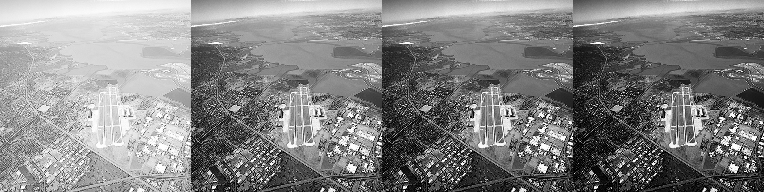

In [2]:
#2-1
img = cv.imread("Fig0309(a)(washed_out_aerial_image).tif")
img = cv.resize(img, dsize=(0,0), fx=0.25, fy=0.25) #1/4로 크기 줄이기

def gamma(f, gamma=1.0):
  f1 = f/255.0 #0~1사이로 정규화
  return np.uint8(255*(f1**gamma)) #L-1*f(i,j)^r
  #-> 다시 8비트 정수(0-255)로 (이미지 출력 함수는 정수 데이터를 취급하기 때문에)

gc = np.hstack((gamma(img, 1.0), gamma(img,3.0), gamma(img,4.0), gamma(img,5.0)))
cv2_imshow(gc)

# L-1*f(i,j)^r
# r<1 = 그래프가 위로 볼록해지며 어두운 부분의 값 커짐 -> 밝아짐
# r>1 = 그래프가 아래로 볼록, 밝은 값들이 작아짐 -> 대비 강해짐
# 첫 사진은 너무 밝아 잘 안보이므로, r 값을 1보다 크게 주면서 전체적으로 어둡게하고 대비를 키움

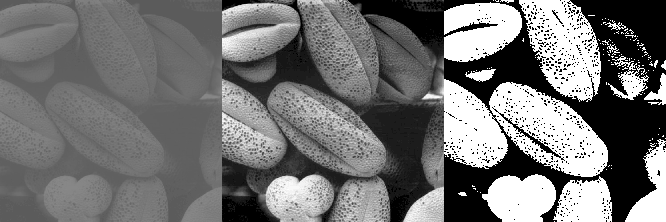

In [3]:
#2-2
img = cv.imread("/content/Fig0310(b)(washed_out_pollen_image).tif", cv.IMREAD_GRAYSCALE)
img = cv.resize(img, dsize=(0,0), fx=0.25, fy=0.25)

# 사진에서의 가장 어두운 값, 밝은 값 밝기 가져오기
r_min = np.min(img)
r_max = np.max(img)

# 범위 지정
pixels=np.arange(256)

lut_val = np.interp(pixels, [r_min, r_max], [0, 255]) #min=0, max=255로 보내고 직선 함수 생성
lut = np.uint8(lut_val)
result_lut = cv.LUT(img, lut) #lut에 따라 모든 픽셀값 한번에 치환

#otsu 알고리즘 사용해 중간값 찾고 이진화
otsu, img_re = cv.threshold(img, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

result = np.hstack((img, result_lut, img_re))
cv2_imshow(result)

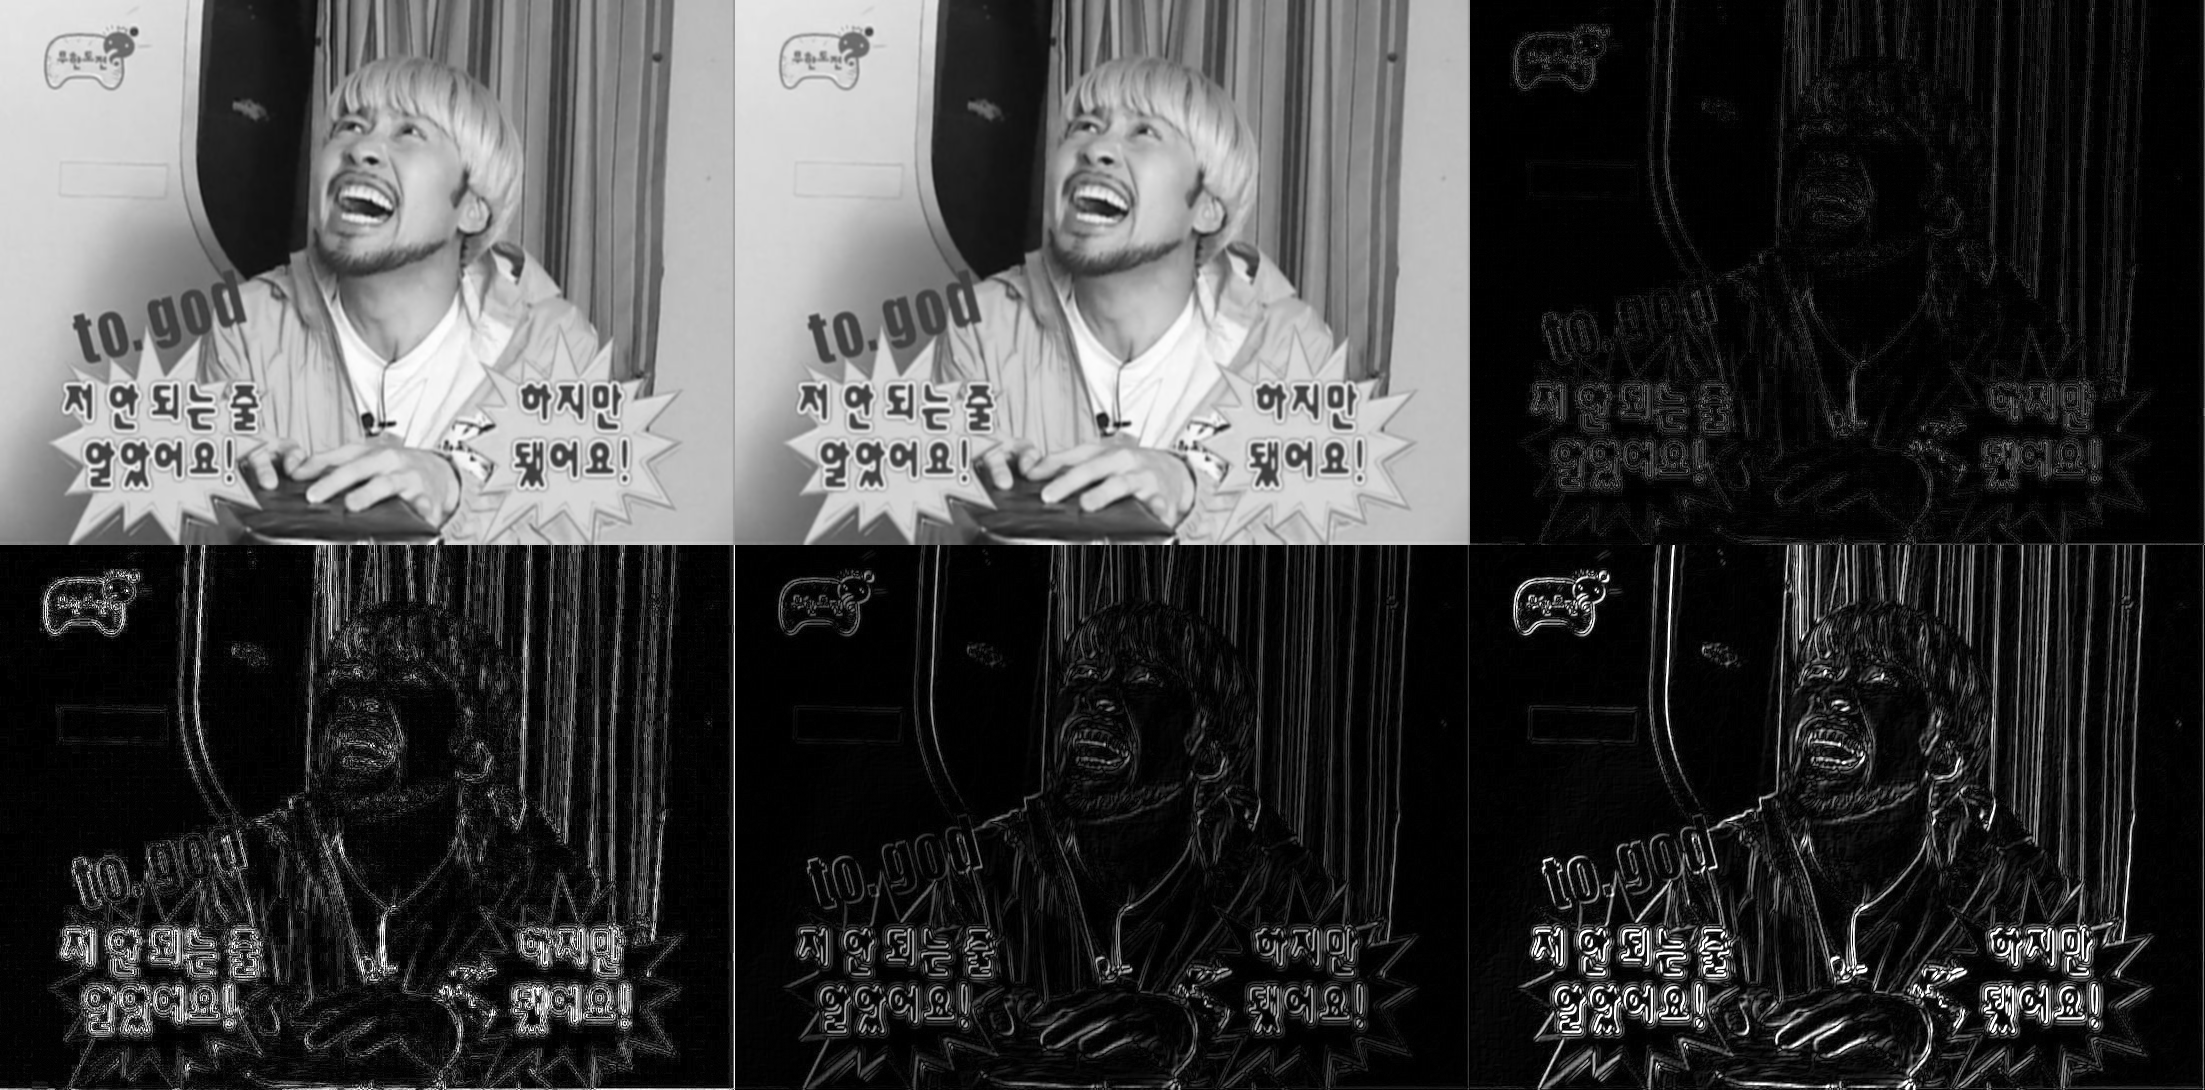

In [8]:
#2-3
img = cv.imread('good.jpg',cv.IMREAD_GRAYSCALE)

kernel1 = np.ones((3,3), np.float32)/9 #모든 값이 1인 3*3 행렬 생성 ->평균
kernel2 = np.array([
    [0.0030, 0.0133, 0.0219, 0.0133, 0.0030],
    [0.0133, 0.0596, 0.0983, 0.0596, 0.0133],
    [0.0219, 0.0983, 0.1621, 0.0983, 0.0219],
    [0.0133, 0.0596, 0.0983, 0.0596, 0.0133],
    [0.0030, 0.0133, 0.0219, 0.0133, 0.0030]
], np.float32) #가우시안 필터 -> 부드러운 평균

kernel3 = np.array([[0, -1, 0], [-1, 4, -1], [0, -1, 0]], np.float32) #라플라시안 4-이웃
kernel4 = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]], np.float32) #라플라시안 8-이웃
kernel5 = np.array([[-1, 0, 0], [0, 0, 0], [0, 0, 1]], np.float32) # 대각선 에지
kernel6 = np.array([[-1, -1, 0], [-1, 0, 1], [0, 1, 1]], np.float32) #대각선 에지 - 엠보싱 효과

# cv.filter2D (원본, 출력깊이, 마스크) -> 컨볼루션 합성곱 수행
#-1 = 입력 이미지와 같은 데이터 타입
result1 = cv.filter2D(img, -1, kernel1)
result2 = cv.filter2D(img, -1, kernel2)

# 음수값으로 [0,255] 벗어나는 문제 방지하기 위해 int16으로 바꾸고 다시 절대값 취해서 변환
result3 = cv.convertScaleAbs(cv.filter2D(img, cv.CV_16S, kernel3))
result4 = cv.convertScaleAbs(cv.filter2D(img, cv.CV_16S, kernel4))
result5 = cv.convertScaleAbs(cv.filter2D(img, cv.CV_16S, kernel5))
result6 = cv.convertScaleAbs(cv.filter2D(img, cv.CV_16S, kernel6))

# 출력
row1 = np.hstack((result1, result2, result3))
row2 = np.hstack((result4, result5, result6))
prt = np.vstack((row1, row2))
cv2_imshow(prt)

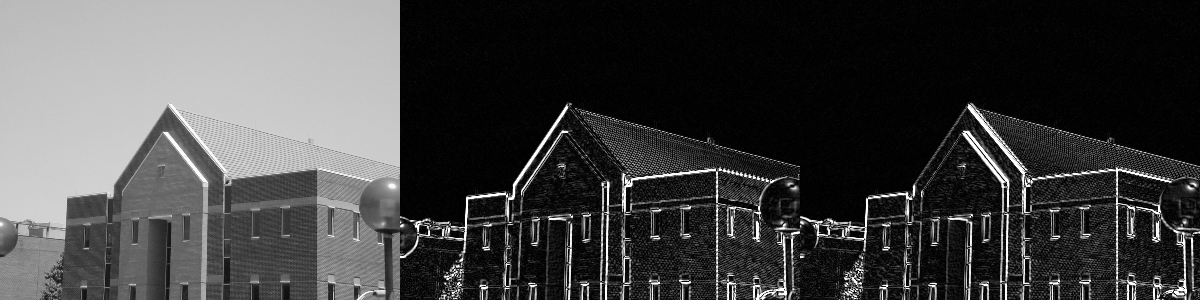

In [6]:
#2-4
img = cv.imread('school.jpg')
img = cv.resize(img, dsize=(0,0), fx=0.25, fy=0.25)

# 대각선 소벨 마스크
# 1. 원래는 중심 픽셀에 가중치를 두어 엣지를 더 잘 찾아낸다면,
# 마스크를 45도 돌려 가중치를 대각선으로 -> 우상향 선분에 강하게 반응
sobel_r = np.array([
    [-2, -1,  0],
    [-1,  0,  1],
    [ 0,  1,  2]
], np.float32) # 오른쪽으로 돌리기

## 2. 마찬가지로 -45도 방향으로 돌림 -> 가중치 대각선으로 가며 우하향에 강하게 반응
sobel_l = np.array([
    [ 0,  1,  2],
    [-1,  0,  1],
    [-2, -1,  0]
], np.float32) # 왼쪽으로 돌리기

# 마스크 적용 - 컨볼루션 연산
grad_r = cv.filter2D(img, cv.CV_32F, sobel_r)
grad_l = cv.filter2D(img, cv.CV_32F, sobel_l)

# 절댓값 취하고 8비트로 변환
edge_r = cv.convertScaleAbs(grad_r)
edge_l = cv.convertScaleAbs(grad_l)

result = np.hstack((img, edge_r, edge_l))
cv2_imshow(result)

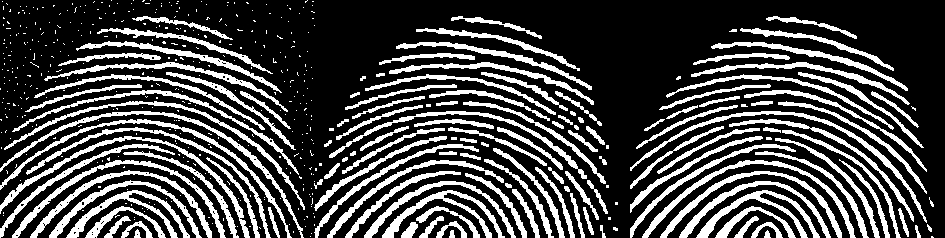

In [17]:
#2-5
img = cv.imread('finger.jpg')

kernel = np.ones((3, 3), np.uint8)


# 모폴로지 연산자 사용 cv.morphologyEx(입력 이미지, 연산, 커널)
opening = cv.morphologyEx(img, cv.MORPH_OPEN, kernel)
# 오프닝한 결과를 클로징
result1 = cv.morphologyEx(opening, cv.MORPH_CLOSE, kernel)

# 미디안 필터 + 바이레터럴 필터 사용
# => 열기, 닫기에 비해 원본을 잘 보존하면서 노이즈 제거 가능

# 미디안 필터 :
# 주변 픽셀 모아두고 정렬 후 중앙값을 고름 -> 이상치 잡음들 사라짐
# -> 지문의 두께 건드리지 않음
median_filtered = cv.medianBlur(img, 5)

# 바이레터럴 필터 -> 가깝고 밝기 비슷한 픽셀만 평균내어 스무딩
# 선 내부는 부드럽지만, 선 경계선은 날카로움 유지
bilateral_filtered = cv.bilateralFilter(median_filtered, 5, 75, 75)

prt = np.hstack((img, result1, bilateral_filtered))
cv2_imshow(prt)

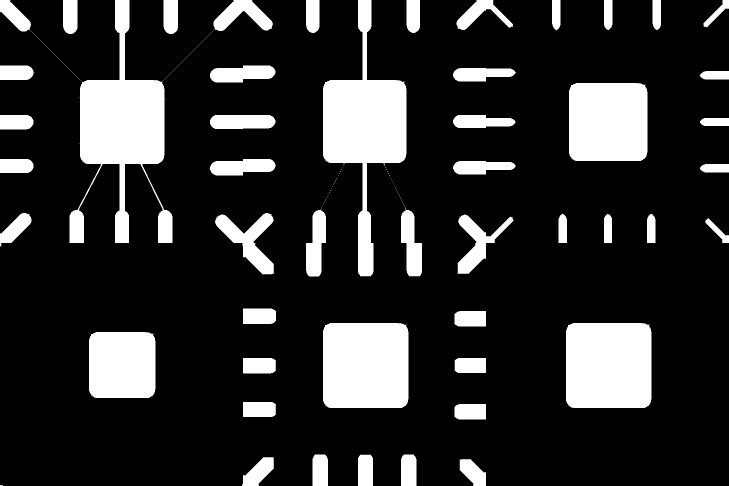

In [27]:
#2-6
img = cv.imread('Fig0905(a)(wirebond-mask).tif')
img = cv.resize(img, dsize=(0,0), fx=0.5, fy=0.5)


# 커널이 커질수록 깎여나가는 선분 수가 많아진다.
# 침식 연산은 커널 내 모든 픽셀이 흰 색일때 중심 픽셀이 유지되는데,커널 크기가 크면
# 배경 포함 확률이 증가하고, 깎여나가는 경계선 두께가 커져 많은 요소가 깎이게 된다
result1 = cv.erode(img, np.ones((2, 2), np.uint8)) # 크기가 작아 얇은 선분까지 살아남음
result2 = cv.erode(img, np.ones((3, 3), np.uint8))
result3 = cv.erode(img, np.ones((8, 8), np.uint8))
result4 = cv.erode(img, np.ones((20, 20), np.uint8)) #크기가 커져 두꺼운 선분까지 모두 사라짐


#opening, closing도 동일
opening = cv.morphologyEx(img, cv.MORPH_OPEN, np.ones((10, 10), np.uint8))
result5 = cv.morphologyEx(opening, cv.MORPH_CLOSE, np.ones((5, 5), np.uint8))

opening = cv.morphologyEx(img, cv.MORPH_OPEN, np.ones((40, 40), np.uint8))
result6 = cv.morphologyEx(opening, cv.MORPH_CLOSE, np.ones((5, 5), np.uint8))

prt1 = np.hstack((result1, result2, result3))
prt2 = np.hstack ((result4, result5, result6))
prt = np.vstack((prt1, prt2))
cv2_imshow(prt)

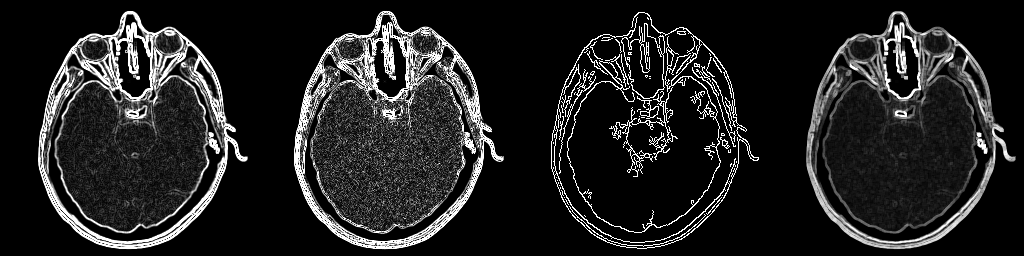

In [34]:
#2-7
img = cv.imread('Fig0939(a)(headCT-Vandy).tif', cv.IMREAD_GRAYSCALE)
img = cv.resize(img, dsize=(0,0), fx=0.5, fy=0.5)

# sobel - 이미지 밝기 변하는 정도 계산하는 1차 미분 연산
# 1차 미분으로 구하기 때문에 밝기가 조금이라도 변하면 에지로 판단
# 노이즈에 강하지만 완벽하게 무시하지는 못함

x = cv.Sobel(img, cv.CV_32F, 1, 0, ksize=3)
y = cv.Sobel(img, cv.CV_32F, 0, 1, ksize=3)
sobel = cv.addWeighted(np.abs(x), 0.5, np.abs(y), 0.5, 0)

# Laplacian - 무방향 2차 미분. 주변 8방향의 변화 한번에 잡음
# 2차 미분이라 노이즈에 취약하고 대비가 감소한다
# 안쪽 노이즈가 많이 보이고, sobel 결과와 비교했을 때 경계선이 뚜렷하지 않아 대비가 적다.
lap = np.abs(cv.Laplacian(img, cv.CV_32F, ksize=3))

# Canny - 에지에서 가장 큰 점만 남기고 나머지 제거
# 1픽셀만 남기므로 가늘고 선명한 이진화
canny = cv.Canny(img, 50, 400)

# Morphological Gradien
# 내부/외부 경계에서 원본 영상 제거하므로 일정한 두께를 가짐
kernel = cv.getStructuringElement(cv.MORPH_RECT, (3, 3))
grad = cv.morphologyEx(img, cv.MORPH_GRADIENT, kernel)

prt = np.hstack((sobel, lap, canny, grad))
cv2_imshow(prt)

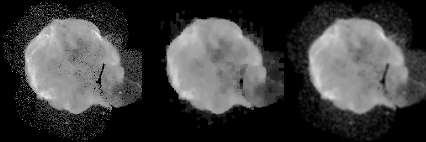

In [38]:
#2-8
img = cv.imread('Fig0938(a)(cygnusloop_Xray_original).tif')
img = cv.resize(img, dsize=(0,0), fx=0.25, fy=0.25)

kernel = np.ones((3,3), np.uint8)

# morphology : Opening, Closing 결합해 스무딩을 수행하므로 노이즈가 제거됨
opening = cv.morphologyEx(img, cv.MORPH_OPEN, kernel)
mor_smoothing = cv.morphologyEx(opening, cv.MORPH_CLOSE, kernel)

# 기본 box blur : 주변값을 평균내어 블러 처리 -> 노이즈가 뿌옇게 변하지만 남아있음
smoothing_filter = cv.blur(img, (3, 3))

prt = np.hstack((img, mor_smoothing, smoothing_filter))
cv2_imshow(prt)

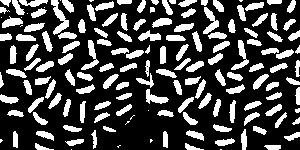

In [39]:
#2-9
img = cv.imread('Fig0940(a)(rice_image_with_intensity_gradient).tif', cv.IMREAD_GRAYSCALE)
img = cv.resize(img, dsize=(0,0), fx=0.25, fy=0.25)

# 이미지를 흑, 백으로 나누고, 최대 최소 정함
# 기준 넘으면 흰색 못넘으면 검은색 -> OTSU를 통해 히스토그램 자동 분석해 기준값 찾음
otsu_th, result1 = cv.threshold(img, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

#Top-hat 전처리를 위한 커널 생성
# 쌀알보다 마스크 크기가 커야함
kernel = np.ones((40, 40), np.uint8)

# 열림 연산으로 배경 추출, 원래 영상에서 제거 -> 조명 불균형을 잡음 = 배경 전체가 0에 가깝게 평탄화
# MORPH_TOPHAT : 탑햇 연산 플래그
top_hat = cv.morphologyEx(img, cv.MORPH_TOPHAT, kernel)

# 조명 평탄화 영상 이진화 수행
top_hat_th,result2 = cv.threshold(top_hat, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

prt = np.hstack((result1, result2))
cv2_imshow(prt)

# 1. OTSU : 히스토그램을 자동 분석해 이진화를 시켜줌
#   -> 배경이 불균형한 탓에 조명이 밝은 쪽은 쌀알이 아닌 배경도 하얗게 이진화 되어버리고 조명이 어두운 쪽은 이진화 과정에서 쌀알도 까맣게 되어버림
# 2.Top-hat : 열림 연산을 통해 배경을 추출해서 제거하기 때문에 배경이 전부 0에 가깝게 평탄화되며 조명 불균형이 잡힌다
#   -> OTSU와 달리 밝은 조명 부분의 배경은 잘 날아가고 어두운 부분의 쌀알도 배경에 먹히지 않고 잘 나온다

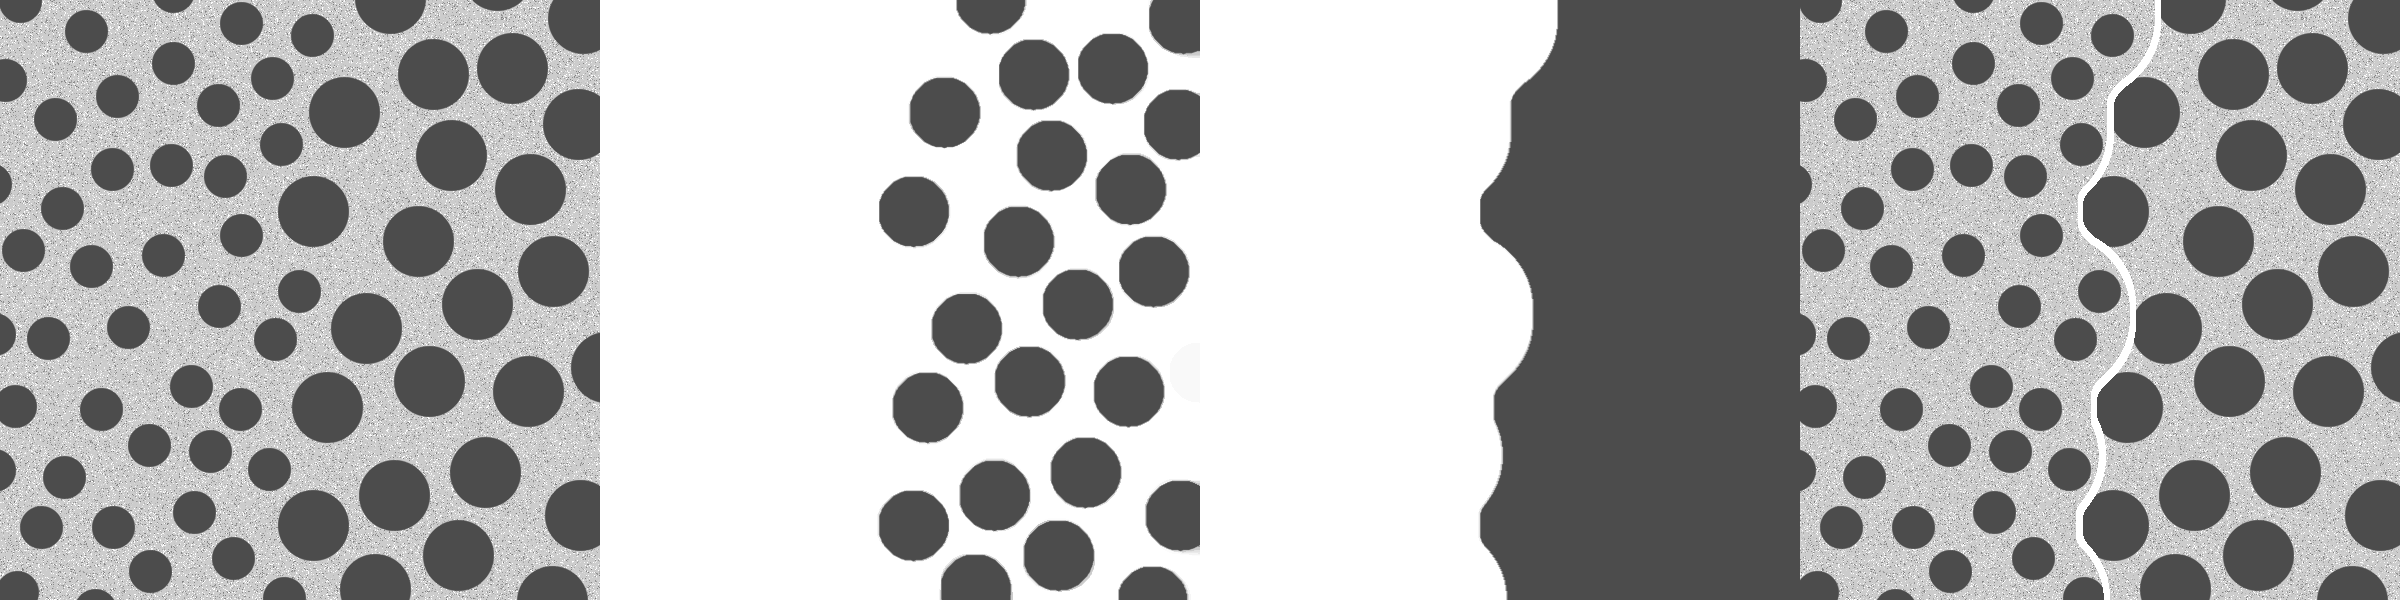

In [63]:
# 2-10
img = cv.imread('Fig0943(a)(dark_blobs_on_light_background).tif', cv.IMREAD_GRAYSCALE)

# 동그란 커널 만들어 closing 수행 -> 검은 커널들 메워버림
k1 = cv.getStructuringElement(cv.MORPH_ELLIPSE, (60, 60))
b = cv.morphologyEx(img, cv.MORPH_CLOSE, k1)

# 큰 커널로 열기 수행하면 큰 점들 사이 흰 부분 제거 -> 까만 배경으로
k2 = cv.getStructuringElement(cv.MORPH_ELLIPSE, (150, 150))
c = cv.morphologyEx(b, cv.MORPH_OPEN, k2)

# MORPH_GRADIENT를 통해 팽창 - 침식을 하며 경계선만 따냄
k3 = np.ones((5, 5), np.uint8)
d = cv.morphologyEx(c, cv.MORPH_GRADIENT, k3)

# 원본 이미지 복사해서 위에 경계선만 칠함
a = img.copy()
a[d>0] = 255 # bool 행렬 만들어 1인 부분만 하얗게 색칠

prt = np.hstack((img, b, c, a))
cv2_imshow(prt)